# Unit 3 code companion: The Normal Distribution and the CLT

The sticky-note demo, run 20,000 times: watch a badly skewed population turn into a bell curve once you average it, find out how big n really has to be, and check whether a 95% interval actually covers 95% of the time.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## 1. The CLT, watched happening

Start from a population that looks nothing like a bell curve, then average it.

population: mean 1.42, median 0.56, skewness 4.15


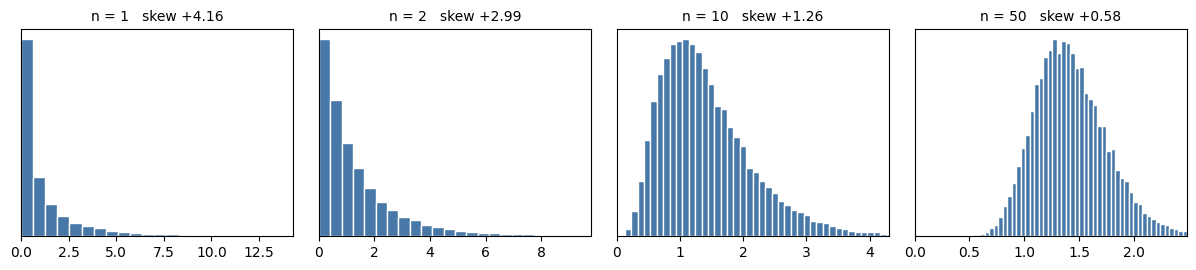

In [2]:
population = rng.exponential(1.0, 400_000) ** 1.6      # badly right-skewed
print(f"population: mean {population.mean():.2f}, median {np.median(population):.2f}, "
      f"skewness {stats.skew(population):.2f}")

fig, axes = plt.subplots(1, 4, figsize=(12, 2.8))
for ax, n in zip(axes, [1, 2, 10, 50]):
    means = population[rng.integers(0, len(population), size=(20_000, n))].mean(axis=1)
    ax.hist(means, bins=60, color="#4878a8", edgecolor="white", density=True)
    ax.set_title(f"n = {n}   skew {stats.skew(means):+.2f}", fontsize=10)
    ax.set_yticks([]); ax.set_xlim(0, np.percentile(means, 99.5))
plt.tight_layout(); plt.show()

Track the skewness number, not the picture. It starts near 4 and collapses toward 0. The CLT is not a claim that the data changes. It is a claim about what happens to the *average* of the data.

## 2. Standard deviation is not standard error



In [3]:
sample = population[rng.integers(0, len(population), 900)]
print(f"SD of the individual values (describes people)   : {sample.std(ddof=1):.3f}")
print(f"SE of the mean = SD/sqrt(n) (describes estimate) : {sample.std(ddof=1)/np.sqrt(900):.3f}")
print()
print("Same data, two questions:")
print(f"  'how different are two random cases?'  -> use the SD  ({sample.std(ddof=1):.2f})")
print(f"  'how well do we know the average?'     -> use the SE  ({sample.std(ddof=1)/30:.2f})")

SD of the individual values (describes people)   : 2.657
SE of the mean = SD/sqrt(n) (describes estimate) : 0.089

Same data, two questions:
  'how different are two random cases?'  -> use the SD  (2.66)
  'how well do we know the average?'     -> use the SE  (0.09)


## 3. How big does n have to be? It depends on the shape.

The honest test of the CLT is not 'does the histogram look bell-shaped' but 'does a 95% confidence interval actually cover the truth 95% of the time?'

In [4]:
def coverage(draw, truth, n, reps=4000):
    x = draw((reps, n))
    m, s = x.mean(axis=1), x.std(axis=1, ddof=1)
    tcrit = stats.t.ppf(0.975, n-1)
    lo, hi = m - tcrit*s/np.sqrt(n), m + tcrit*s/np.sqrt(n)
    return ((lo <= truth) & (truth <= hi)).mean()

cases = {
    "normal        ": (lambda sz: rng.normal(0, 1, sz), 0.0),
    "mildly skewed ": (lambda sz: rng.exponential(1, sz), 1.0),
    "badly skewed  ": (lambda sz: rng.lognormal(0, 1.8, sz), np.exp(1.8**2/2)),
    "rare event 1% ": (lambda sz: (rng.random(sz) < 0.01).astype(float), 0.01),
}
print(f"{'population':>15} " + "".join(f"{('n='+str(n)):>9}" for n in [5, 30, 100, 1000]))
for name, (draw, truth) in cases.items():
    print(f"{name:>15} " + "".join(f"{coverage(draw, truth, n):>9.3f}" for n in [5, 30, 100, 1000]))
print("\n(every cell should be 0.95 if the interval is honest)")

     population       n=5     n=30    n=100   n=1000
 normal             0.949    0.951    0.944    0.951
 mildly skewed      0.880    0.929    0.946    0.948
 badly skewed       0.610    0.705    0.787    0.882
 rare event 1%      0.054    0.256    0.636    0.930

(every cell should be 0.95 if the interval is honest)


This table is the real answer to 'is n=30 enough?'. For symmetric data even n=5 is nearly fine. For a badly skewed population, n=30 intervals cover well below 95%, so you are overconfident far more often than you think. For a 1% rare event, n=30 is hopeless: most samples contain zero events, the SD is estimated as 0, and the interval collapses.

## 4. Real data: what actually happens with rent



In [5]:
rent = pd.read_csv("https://richardson.byu.edu/220/rent.csv")
r = rent["Rent"].values
print(f"n = {len(r)},  mean = {r.mean():,.0f},  median = {np.median(r):,.0f},  SD = {r.std():,.0f}")

# Fit a normal by moments and ask it something absurd.
p_negative = stats.norm.cdf(0, r.mean(), r.std())
print(f"\nA normal with this mean and SD says {p_negative:.1%} of listings have NEGATIVE rent.")
print("The variable is not normal. That does not stop us estimating its MEAN with normal theory:")
print(f"  SE of the mean = {r.std(ddof=1)/np.sqrt(len(r)):,.0f}")
print(f"  95% CI for mean rent = [{r.mean() - 1.96*r.std(ddof=1)/np.sqrt(len(r)):,.0f}, "
      f"{r.mean() + 1.96*r.std(ddof=1)/np.sqrt(len(r)):,.0f}]")

n = 4743,  mean = 35,010,  median = 16,000,  SD = 78,120

A normal with this mean and SD says 32.7% of listings have NEGATIVE rent.
The variable is not normal. That does not stop us estimating its MEAN with normal theory:
  SE of the mean = 1,134
  95% CI for mean rent = [32,786, 37,234]


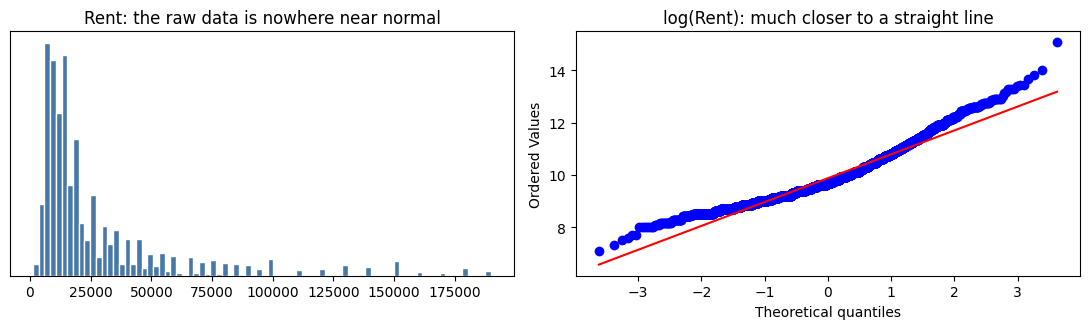

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(r[r < 200_000], bins=80, color="#4878a8", edgecolor="white")
axes[0].set_title("Rent: the raw data is nowhere near normal"); axes[0].set_yticks([])
stats.probplot(np.log(r), dist="norm", plot=axes[1])
axes[1].set_title("log(Rent): much closer to a straight line")
plt.tight_layout(); plt.show()

## 5. Where averaging stops working

The CLT needs a finite variance. Heavy-tailed data can violate that, and then no sample size saves you.

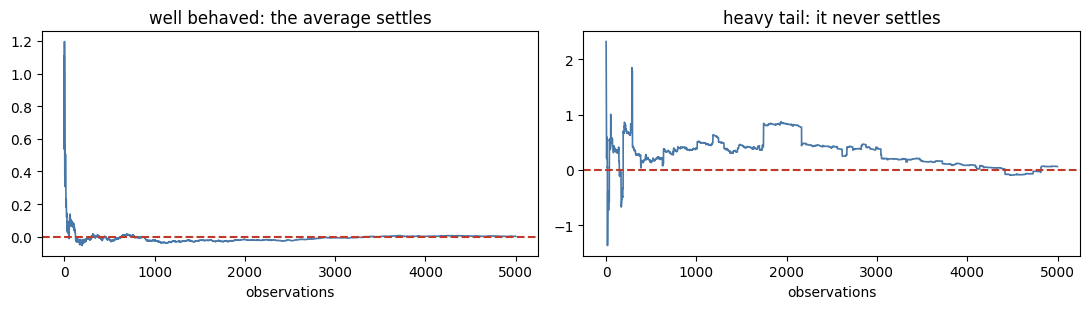

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, draws, title in [
        (axes[0], rng.normal(0, 1, 5000), "well behaved: the average settles"),
        (axes[1], rng.standard_cauchy(5000), "heavy tail: it never settles")]:
    ax.plot(np.cumsum(draws)/np.arange(1, len(draws)+1), color="#4878a8", lw=1.2)
    ax.axhline(0, color="#c0392b", ls="--"); ax.set_title(title); ax.set_xlabel("observations")
plt.tight_layout(); plt.show()

## 6. Dependence: when n is not n

The CLT assumes independent draws. Real data is full of repeated measurements.

In [8]:
def ar1(n, rho, reps):
    """Each observation is correlated with the previous one."""
    e = rng.normal(size=(reps, n))
    x = np.zeros((reps, n))
    x[:, 0] = e[:, 0]
    for t in range(1, n):
        x[:, t] = rho*x[:, t-1] + np.sqrt(1-rho**2)*e[:, t]
    return x

for rho in [0.0, 0.3, 0.6, 0.9]:
    x = ar1(200, rho, 4000)
    m, s = x.mean(axis=1), x.std(axis=1, ddof=1)
    lo, hi = m - 1.96*s/np.sqrt(200), m + 1.96*s/np.sqrt(200)
    cover = ((lo <= 0) & (0 <= hi)).mean()
    eff_n = 200 * (1-rho)/(1+rho)
    note = "independent, so n really is 200" if rho == 0 else f"effective n is about {eff_n:.0f}, not 200"
    print(f"correlation {rho:.1f}: 95% CI actually covers {cover:5.1%}   ({note})")

correlation 0.0: 95% CI actually covers 94.7%   (independent, so n really is 200)
correlation 0.3: 95% CI actually covers 84.9%   (effective n is about 108, not 200)
correlation 0.6: 95% CI actually covers 68.2%   (effective n is about 50, not 200)
correlation 0.9: 95% CI actually covers 33.1%   (effective n is about 11, not 200)


At a correlation of 0.6 your '95%' interval covers about two-thirds of the time. Nothing in the output warns you: the code runs, the number is small, and the conclusion is wrong. This is why the first question about any dataset is *what is one independent observation?*